In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv("laptop_price.csv",encoding='latin-1')

In [34]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [35]:
df.shape

(1303, 13)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [37]:
df.isnull().sum()

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

In [38]:
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


In [39]:
df.duplicated().sum()

0

In [40]:
df.columns

Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_euros'],
      dtype='object')

In [41]:
df['Ram'] = df['Ram'].str.replace('GB','').astype(int)
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)


In [42]:
category = ['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Memory', 'Gpu', 'OpSys']

In [43]:
df_encoded = pd.get_dummies(df, columns=category, drop_first=True)

In [44]:
df_encoded = df_encoded.drop(columns=['laptop_ID', 'Product'])

In [45]:
df_encoded.head()

,Inches,Ram,Weight,Price_euros,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,Company_Google,...,Gpu_Nvidia Quadro M620,Gpu_Nvidia Quadro M620M,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,13.3,8,1.37,1339.69,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,13.3,8,1.34,898.94,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,15.6,8,1.86,575.00,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,15.4,16,1.83,2537.45,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,13.3,8,1.37,1803.60,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [46]:
df_encoded = df_encoded.astype(int)

In [47]:
df_encoded

,Inches,Ram,Weight,Price_euros,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,Company_Google,...,Gpu_Nvidia Quadro M620,Gpu_Nvidia Quadro M620M,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,13,8,1,1339,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,13,8,1,898,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,15,8,1,575,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,15,16,1,2537,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,13,8,1,1803,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,14,4,1,638,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1299,13,16,1,1499,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1300,14,2,1,229,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1301,15,6,2,764,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [48]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Columns: 338 entries, Inches to OpSys_macOS
dtypes: int64(338)
memory usage: 3.4 MB


## Feature Scaling

Apply feature scaling to numerical features using a technique like StandardScaler.


In [49]:
from sklearn.preprocessing import StandardScaler

numerical_features = ['Inches', 'Ram', 'Weight']

scaler = StandardScaler()

df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

In [50]:

from sklearn.model_selection import train_test_split
X = df_encoded.drop('Price_euros', axis=1)
y = df_encoded['Price_euros']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
X_train.shape

(1042, 337)

In [53]:
y_train.shape

(1042,)

## Build the Artificial Neural Network (ANN) Model

In [54]:
#import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [55]:
# 1. Initialize a Sequential model instance
model = Sequential()

In [56]:
# The input_shape should match the number of features in X_train
input_dim = X_train.shape[1]
model.add(Dense(units=128, activation='relu', input_shape=(input_dim,))) #kernel_regularizer=l2(0.001)
model.add(Dropout(0.2))

print(f"Input layer added with {input_dim} features and 128 units.")

Input layer added with 337 features and 128 units.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
# 3. Add one or more hidden layers
model.add(Dense(units=128, activation='relu'))  #kernel_regularizer=l2(0.001)
model.add(Dropout(0.2))
model.add(Dense(units=64, activation='relu'))#kernel_regularizer=l2(0.001)
model.add(Dropout(0.2))
model.add(Dense(units=32, activation='relu'))#kernel_regularizer=l2(0.001)
model.add(Dropout(0.2))

In [58]:
# 4. Add the output layer for regression
# 1 neuron for a single regression output (price prediction), no activation function (linear output)
model.add(Dense(units=1, activation='linear'))

In [59]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │        43,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,145 (274.00 KB)

 Trainable params: 70,145 (274.00 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
from tensorflow.keras.callbacks import EarlyStopping
early = EarlyStopping(monitor='val_loss', mode='auto', verbose=1, patience=10)

In [61]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

In [62]:
print("Starting model training...")

history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1,callbacks=[early])

print("Model training complete.")

Starting model training...


Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1830654.7500 - mean_absolute_error: 1151.0256 - val_loss: 1734871.2500 - val_mean_absolute_error: 1131.5487
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1718183.0000 - mean_absolute_error: 1099.3809 - val_loss: 1264866.8750 - val_mean_absolute_error: 913.8425
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 877934.0625 - mean_absolute_error: 690.9966 - val_loss: 334417.2500 - val_mean_absolute_error: 477.7580
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 319539.9688 - mean_absolute_error: 446.9529 - val_loss: 205277.7344 - val_mean_absolute_error: 304.6489
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 189661.7969 - mean_absolute_error: 322.4634 - val_loss: 173858.2188 - val_mean_absolute_error: 283.1217
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 165157.5312 - mean_absolute_error: 287.0427 - val_loss: 165103.3906 - val_mean_absolute_error: 267.2300
Epoch 7/100
27/

In [63]:
y_pred = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [64]:
y_pred_train = model.predict(X_train)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step


In [65]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2_score = r2_score(y_test, y_pred)

In [66]:
print(f"Testing Mean Squared Error (MSE): {mse}")
print(f"Testing Mean Absolute Error (MAE): {mae}")
print(f"Testing R2 Score: {r2_score}")

Testing Mean Squared Error (MSE): 69136.07851252482
Testing Mean Absolute Error (MAE): 176.6939651664646
Testing R2 Score: 0.8638818239264441


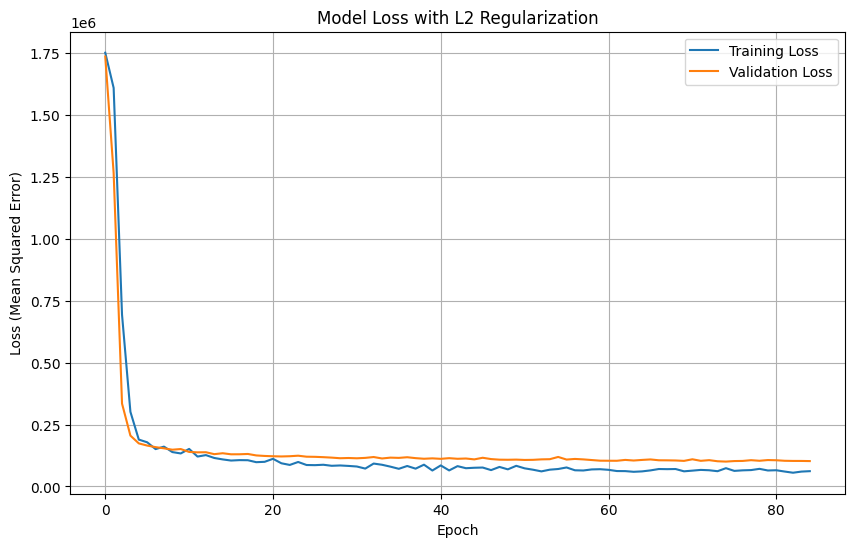

In [67]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss with L2 Regularization')
plt.ylabel('Loss (Mean Squared Error)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()